<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 78 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">ANOVA 📊</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">When you have three or more groups, running every pairwise t-test inflates the error rate. ANOVA tests them all at once with the F statistic, and Tukey HSD pinpoints which differ. We apply both to three shipping carriers.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(78)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · WHY NOT MANY t-TESTS?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Comparing 3+ groups inflates the error rate</div>
<div style="color:#4a5578;margin-top:6px">With 3 groups there are 3 possible pairwise t-tests; with 5 groups, 10. Each carries a 5% false-alarm risk, so running them all balloons the chance of a spurious 'difference'. ANOVA tests 'are ALL the means equal?' in ONE test at one alpha.</div>
</div>

In [2]:
from itertools import combinations
# simulate: 5 groups, all identical (H0 true). How often does ANY pairwise t-test fire?
def any_pairwise_hit(k=5,n=30):
    gs=[rng.normal(0,1,n) for _ in range(k)]
    return any(stats.ttest_ind(a,b).pvalue<0.05 for a,b in combinations(gs,2))
rate=np.mean([any_pairwise_hit() for _ in range(3000)])
print(f"5 identical groups: P(at least one pairwise t-test significant) = {rate:.2f}")
print("Far above 0.05 -> multiple comparisons inflate the family-wise error. ANOVA fixes this.")

5 identical groups: P(at least one pairwise t-test significant) = 0.27
Far above 0.05 -> multiple comparisons inflate the family-wise error. ANOVA fixes this.


Ten independent 5% tests give roughly a 1&#8722;0.95&#185;&#8304; &#8776; 40% chance of at least one false alarm. ANOVA restores a single, honest 5% by asking one global question first: <em>is there any difference at all?</em>

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · THE F STATISTIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Between-group spread vs within-group spread</div>
<div style="color:#4a5578;margin-top:6px">ANOVA compares two kinds of variation. If the group means are far apart RELATIVE to the noise within groups, their ratio, the F statistic, is large. F = (variance between group means) / (variance within groups). Under H0 (all equal), F is near 1.</div>
</div>

In [3]:
# three groups with genuinely different means
g1=rng.normal(50,8,40); g2=rng.normal(55,8,40); g3=rng.normal(62,8,40)
F,p=stats.f_oneway(g1,g2,g3)
print(f"means: {g1.mean():.1f}, {g2.mean():.1f}, {g3.mean():.1f}")
print(f"F={F:.2f}, p={p:.2e}  -> reject H0: not all means are equal")
# contrast: three IDENTICAL groups -> F near 1, p large
h=[rng.normal(50,8,40) for _ in range(3)]; F0,p0=stats.f_oneway(*h)
print(f"identical groups: F={F0:.2f}, p={p0:.2f}  -> fail to reject (as expected)")

means: 49.1, 56.2, 61.7
F=24.88, p=9.95e-10  -> reject H0: not all means are equal
identical groups: F=1.09, p=0.34  -> fail to reject (as expected)


A large F means the gaps between group means dwarf the within-group noise, evidence the groups really differ. Under the null, between and within variation are the same kind of thing, so F hovers around 1. The p-value comes from the F distribution with (k&#8722;1, N&#8722;k) degrees of freedom.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · POST-HOC: TUKEY HSD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A significant F says 'someone differs', but who?</div>
<div style="color:#4a5578;margin-top:6px">ANOVA's F is an omnibus test: it flags that SOME pair differs, not which. Tukey's Honest Significant Difference compares every pair while controlling the family-wise error rate, so you can read off exactly which groups separate.</div>
</div>

In [4]:
def tukey_hsd(groups, names, alpha=0.05):
    from scipy.stats import studentized_range
    k=len(groups); N=sum(len(g) for g in groups); dfw=N-k
    grand=np.concatenate(groups)
    ssw=sum(((g-g.mean())**2).sum() for g in groups); msw=ssw/dfw
    qcrit=studentized_range.ppf(1-alpha, k, dfw)
    print(f"MSW={msw:.3f}, df_within={dfw}, q*({k},{dfw})={qcrit:.3f}")
    out=[]
    for i in range(k):
        for j in range(i+1,k):
            diff=groups[i].mean()-groups[j].mean()
            se=np.sqrt(msw/2*(1/len(groups[i])+1/len(groups[j])))
            hsd=qcrit*se; sig="YES" if abs(diff)>hsd else "no"
            out.append((names[i],names[j],diff,diff-hsd,diff+hsd,sig))
            print(f"  {names[i]:>12} vs {names[j]:<12}: diff={diff:+6.2f}  95% CI [{diff-hsd:+6.2f},{diff+hsd:+6.2f}]  sig={sig}")
    return out

In [5]:
g1=rng.normal(50,8,50); g2=rng.normal(52,8,50); g3=rng.normal(60,8,50)
F,p=stats.f_oneway(g1,g2,g3); print(f"ANOVA F={F:.2f}, p={p:.2e}\n")
_=tukey_hsd([g1,g2,g3], ["A","B","C"])

ANOVA F=18.24, p=8.37e-08

MSW=62.224, df_within=147, q*(3,147)=3.348
             A vs B           : diff= +0.80  95% CI [ -2.94, +4.54]  sig=no
             A vs C           : diff= -7.82  95% CI [-11.56, -4.09]  sig=YES
             B vs C           : diff= -8.62  95% CI [-12.36, -4.89]  sig=YES


Tukey widens each comparison just enough to keep the <em>overall</em> error at 5% across all pairs. A pair is significant when its confidence interval excludes 0. This is the disciplined way to follow up a significant ANOVA, never a flurry of uncorrected t-tests.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · DELIVERY BY CARRIER</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Do three carriers really differ on delivery time?</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A shipper compares <strong>three carriers</strong> on door-to-door delivery time (`ch78_carrier_delivery.xlsx`), 80 shipments each. Are the average times genuinely different, or is it noise? One-way ANOVA answers the global question; Tukey HSD finds the culprits.

In [6]:
try:    d = pd.read_excel("../../data/ch78_carrier_delivery.xlsx", sheet_name="Shipments")
except FileNotFoundError: d = pd.read_excel(BASE+"ch78_carrier_delivery.xlsx", sheet_name="Shipments")
print("loaded:", d.shape)
groups=[g["delivery_hours"].values for _,g in d.groupby("carrier")]
names=list(d.groupby("carrier").groups.keys())
print("mean hours:", {n:round(g.mean(),2) for n,g in zip(names,groups)})
F,p=stats.f_oneway(*groups)
grand=d.delivery_hours.mean(); ssb=sum(len(g)*(g.mean()-grand)**2 for g in groups); sst=((d.delivery_hours-grand)**2).sum()
print(f"ANOVA: F={F:.2f}, p={p:.2e}, eta^2={ssb/sst:.3f} (share of variance explained by carrier)")
print('-> reject H0: the carriers do NOT all have the same mean delivery time')

loaded: (240, 4)
mean hours: {'FastFreight': np.float64(30.39), 'GroundLink': np.float64(35.87), 'RegionalCo': np.float64(37.4)}
ANOVA: F=22.91, p=7.99e-10, eta^2=0.162 (share of variance explained by carrier)
-> reject H0: the carriers do NOT all have the same mean delivery time


Tukey HSD (which carriers differ?):
MSW=47.434, df_within=237, q*(3,237)=3.335
   FastFreight vs GroundLink  : diff= -5.48  95% CI [ -8.05, -2.91]  sig=YES
   FastFreight vs RegionalCo  : diff= -7.01  95% CI [ -9.58, -4.44]  sig=YES
    GroundLink vs RegionalCo  : diff= -1.53  95% CI [ -4.10, +1.04]  sig=no


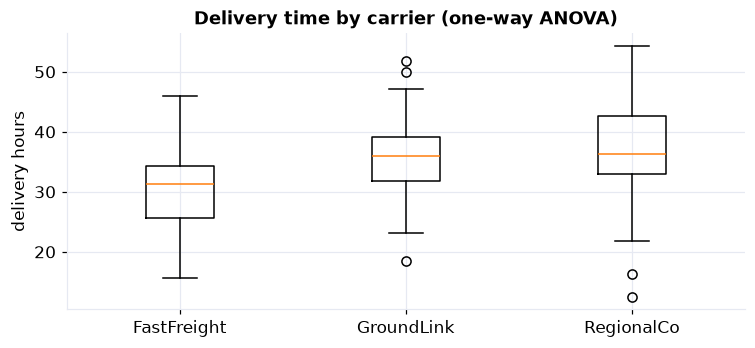

In [7]:
print("Tukey HSD (which carriers differ?):")
_=tukey_hsd(groups, names)
fig,ax=plt.subplots(figsize=(7,3.3))
ax.boxplot(groups, tick_labels=names)
ax.set_ylabel("delivery hours"); ax.set_title("Delivery time by carrier (one-way ANOVA)")
plt.tight_layout(); plt.show()

The F statistic is about <strong>22.9</strong> with a p-value near 10&#8315;&#8313;, so we reject the hypothesis that all three carriers deliver equally fast; carrier explains about <strong>16%</strong> of the variation (&#951;&#178; &#8776; 0.16). Tukey HSD then shows FastFreight (&#8776; 30.4 h) is significantly faster than both GroundLink (&#8776; 35.9 h) and RegionalCo (&#8776; 37.4 h), while GroundLink and RegionalCo are not clearly distinguishable. The omnibus test plus the post-hoc gives the full picture: there is a difference, and it is FastFreight pulling ahead.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ ANOVA</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">ANOVA compares 3+ group means in one test, avoiding the error inflation of many t-tests. The F statistic is between-group variance over within-group variance; large F (small p) rejects "all means equal". A significant F is an omnibus result, so follow it with Tukey HSD to see WHICH pairs differ. On real data, carriers differ (F=22.9, p&#8776;10&#8315;&#8313;, &#951;&#178;&#8776;0.16) with FastFreight the standout. Next: chi-square tests for categorical data.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>